In [ ]:
# ECO491: Homework 5

## Question 1: Hedging Interest Rate Risk

In [15]:
import math
import numpy as np
import matplotlib.pyplot as plt
import os

In [16]:
# Question 1a
beta1, beta2, beta3 = 0.04, 0.012, -0.0015

def R(T, b1=beta1, b2=beta2, b3=beta3):
    return b1 + b2*T + b3*T*T

def discount(T, b1=beta1, b2=beta2, b3=beta3):
    return math.exp(-R(T, b1, b2, b3) * T)

def bond_price(cashflows, b1=beta1, b2=beta2, b3=beta3):
    return sum(cf * discount(T, b1, b2, b3) for (T, cf) in cashflows)

cashflows_bond = [(0.5 * k, 3.0) for k in range(1, 17)]
cashflows_bond[-1] = (8.0, 103.0)

B0 = bond_price(cashflows_bond)
B0

110.85837376637954

In [17]:
# Question 1b
def factor_duration(cashflows, factor, b1=beta1, b2=beta2, b3=beta3):
    if factor not in {"level", "curvature"}:
        raise ValueError("factor must be 'level' or 'curvature'")

    def f(T):
        if factor == "level":
            return 1.0
        if factor == "curvature":
            return T*T

    P = bond_price(cashflows, b1, b2, b3)
    num = sum(cf * T * f(T) * discount(T, b1, b2, b3) for (T, cf) in cashflows)
    return num / P

D_lev_B = factor_duration(cashflows_bond, "level")
D_cur_B = factor_duration(cashflows_bond, "curvature")
D_lev_B, D_cur_B

(6.619230575854974, 380.4949534468068)

In [ ]:
# Question 1c
def zero_price(T, b1=beta1, b2=beta2, b3=beta3):
    return 100.0 * discount(T, b1, b2, b3)

Z1 = zero_price(1.0)
Z7 = zero_price(7.0)
D_lev_z1, D_cur_z1 = 1.0, 1.0
D_lev_z7, D_cur_z7 = 7.0, 7.0**3

B0, Z1, Z7, D_lev_z1, D_cur_z1, D_lev_z7, D_cur_z7

(110.85837376637954, 95.0753928672327, 70.2225992588067, 1.0, 1.0, 7.0, 343.0)

In [ ]:
# Question 1d
A = np.array([[Z1 * D_lev_z1, Z7 * D_lev_z7],
              [Z1 * D_cur_z1, Z7 * D_cur_z7]])
b = -np.array([B0 * D_lev_B, B0 * D_cur_B])

k1, k7 = np.linalg.solve(A, b)
k1, k7

(np.float64(1.3640473132519662), np.float64(-1.7566271512404925))

Scenario  1:  B_i =  101.159,  P_i =  117.318
Scenario  2:  B_i =   92.516,  P_i =  117.664
Scenario  3:  B_i =   84.811,  P_i =  118.177
Scenario  4:  B_i =   77.937,  P_i =  118.816
Scenario  5:  B_i =   71.802,  P_i =  119.546
Scenario  6:  B_i =   66.322,  P_i =  120.338
Scenario  7:  B_i =   61.424,  P_i =  121.167
Scenario  8:  B_i =   57.043,  P_i =  122.012
Scenario  9:  B_i =   53.121,  P_i =  122.859
Scenario 10:  B_i =   49.607,  P_i =  123.693


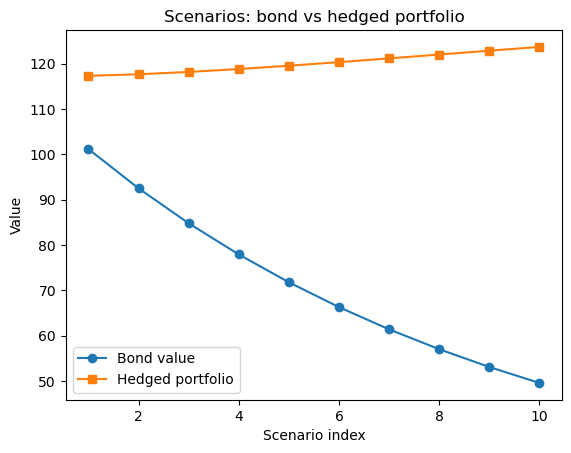

In [ ]:
# Question 1d
def scenario_betas(i):
    b1 = 0.04 + i * 0.025 / 10.0
    b3 = -0.0015 + i * 0.002 / 10.0
    b2 = 0.012
    return b1, b2, b3

B_list, P_list = [], []

for i in range(1, 11):
    b1, b2, b3 = scenario_betas(i)
    B_i = bond_price(cashflows_bond, b1, b2, b3)
    Z1_i = zero_price(1.0, b1, b2, b3)
    Z7_i = zero_price(7.0, b1, b2, b3)
    P_i = B_i + k1 * Z1_i + k7 * Z7_i
    B_list.append(B_i)
    P_list.append(P_i)

for i, (Bi, Pi) in enumerate(zip(B_list, P_list), start=1):
    print(f"Scenario {i:2d}:  B_i = {Bi:8.3f},  P_i = {Pi:8.3f}")

plt.figure()
plt.plot(range(1, 11), B_list, marker='o', label='Bond value')
plt.plot(range(1, 11), P_list, marker='s', label='Hedged portfolio')
plt.xlabel('Scenario index')
plt.ylabel('Value')
plt.title('Scenarios: bond vs hedged portfolio')
plt.legend()

save_folder = "../latex/figures"
os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, "ECO491_HW5_Q1_Model_1.pdf")

plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")

## Question 2 — Bond Convexity

**See the LaTeX file for the full derivation and final formulas for traditional convexity and factor convexities.**

## Question 3 — Black–Scholes Option Pricing via Risk-Neutral Valuation

**See the LaTeX file for the full analytical derivation of the Black–Scholes call price formula.**

## Question 4 — Black–Scholes Delta

Here we implement the Black–Scholes formulas, check delta and vega numerically, and plot delta as a function of the underlying price.

In [21]:
from statistics import NormalDist

phi = NormalDist()

def bs_call(S, K, T, rf, sigma, q=0.0):
    if T <= 0.0 or sigma <= 0.0:
        return max(S*math.exp(-q*T) - K*math.exp(-rf*T), 0.0)
    d1 = (math.log(S/K) + (rf - q + 0.5*sigma*sigma)*T) / (sigma*math.sqrt(T))
    d2 = d1 - sigma*math.sqrt(T)
    return S*math.exp(-q*T)*phi.cdf(d1) - K*math.exp(-rf*T)*phi.cdf(d2)

def bs_put(S, K, T, rf, sigma, q=0.0):
    c = bs_call(S, K, T, rf, sigma, q)
    return c + K*math.exp(-rf*T) - S*math.exp(-q*T)

def bs_delta_call(S, K, T, rf, sigma, q=0.0):
    if T <= 0.0 or sigma <= 0.0:
        return 1.0 if S*math.exp(-q*T) > K*math.exp(-rf*T) else 0.0
    d1 = (math.log(S/K) + (rf - q + 0.5*sigma*sigma)*T) / (sigma*math.sqrt(T))
    return math.exp(-q*T) * phi.cdf(d1)

def bs_vega_call(S, K, T, rf, sigma, q=0.0):
    if T <= 0.0 or sigma <= 0.0:
        return 0.0
    d1 = (math.log(S/K) + (rf - q + 0.5*sigma*sigma)*T) / (sigma*math.sqrt(T))
    return S*math.exp(-q*T) * phi.pdf(d1) * math.sqrt(T)

def check_delta_numeric(S, K, T, rf, sigma, q=0.0, h=1e-4):
    c_plus = bs_call(S + h, K, T, rf, sigma, q)
    c_minus = bs_call(S - h, K, T, rf, sigma, q)
    delta_num = (c_plus - c_minus) / (2.0*h)
    delta_anal = bs_delta_call(S, K, T, rf, sigma, q)
    return delta_anal, delta_num, delta_anal - delta_num

def check_vega_numeric(S, K, T, rf, sigma, q=0.0, h=1e-4):
    c_plus = bs_call(S, K, T, rf, sigma + h, q)
    c_minus = bs_call(S, K, T, rf, sigma - h, q)
    vega_num = (c_plus - c_minus) / (2.0*h)
    vega_anal = bs_vega_call(S, K, T, rf, sigma, q)
    return vega_anal, vega_num, vega_anal - vega_num

# Example check
S, K, T, rf, sigma, q = 100.0, 100.0, 1.0, 0.05, 0.2, 0.0
delta_anal, delta_num, d_diff = check_delta_numeric(S, K, T, rf, sigma, q)
vega_anal, vega_num, v_diff = check_vega_numeric(S, K, T, rf, sigma, q)

print(f"Delta analytic vs numeric: {delta_anal:.8f} vs {delta_num:.8f}, diff={d_diff:.2e}")
print(f"Vega  analytic vs numeric: {vega_anal:.8f} vs {vega_num:.8f}, diff={v_diff:.2e}")

Delta analytic vs numeric: 0.63683065 vs 0.63683065, diff=-6.08e-12
Vega  analytic vs numeric: 37.52403469 vs 37.52403439, diff=3.04e-07


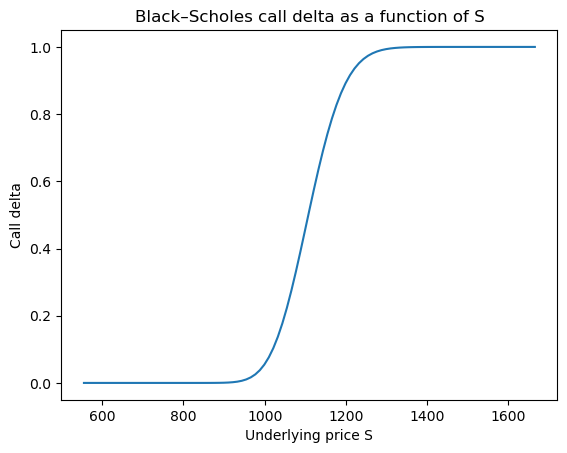

In [22]:
# --- Delta as a function of S (S&P 500 example parameters) ---
K_spx = 1110.0
T_spx = 43.0/365.0
rf_spx = 0.0025
sigma_spx = 0.1872
q_spx = 0.0

S_min = 0.5 * K_spx
S_max = 1.5 * K_spx
n_grid = 101

S_vals = []
delta_vals = []

for i in range(n_grid):
    S_i = S_min + (S_max - S_min) * i / (n_grid - 1)
    d_i = bs_delta_call(S_i, K_spx, T_spx, rf_spx, sigma_spx, q_spx)
    S_vals.append(S_i)
    delta_vals.append(d_i)

plt.figure()
plt.plot(S_vals, delta_vals)
plt.xlabel('Underlying price S')
plt.ylabel('Call delta')
plt.title('Black–Scholes call delta as a function of S')

os.makedirs(save_folder, exist_ok=True)
save_path = os.path.join(save_folder, "ECO491_HW5_Q4_Model_1.pdf")

plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")

## Question 5 — Black–Scholes Implied Volatility and Monotonicity

**See the LaTeX file for the analytical arguments showing that call and put prices are strictly increasing in volatility under Black–Scholes.**